<h1> Differential Evolution (DE) </h1>

DE is a population-based optimization algorithm for continuous optimization problems.

**Core idea:**

DE utilizes the difference between solutions to navigate the search space.

In other words:

The distance and direction of movement between individuals in the population generate search information.

DE Core: Mutation Strategy

*DE/rand/1*

Formula:

$V_i=X_{r1}+F(X_{r2}-X_{r3})$

Parameter $F$ is the Differential Weight.

Key DE Parameters

Three main parameters:

1) F — Differential Weight </br>
The extent to which the difference between individuals is utilized.

Typically:</br>
$0.4 \leq F \leq 1$

1. If F is high:</br>
Larger movement</br>
Result:</br>
Greater exploration</br>
Higher probability of traversing/escaping regions</br>
But:</br>
Greater instability

2. If F is low:</br>
Small movement</br>
Result:</br>
Faster convergence</br>
Less exploration


2) CR — Crossover Rate

After mutation, a decision must be made:</br>
How much of the new vector is incorporated into the original solution.

1. Target Vector</br>
2. Donor (Mutant) Vector</br>
3. Trial Vector


3) Population Size

Like GA Larger population:</br>
1. Greater diversity</br>
2. Higher computational cost</br>
3. General DE Structure

For each individual Xi:</br>
1) Select Xr1, Xr2, Xr3</br>
2) Create Mutant Vector</br>
3) Crossover with Xi</br>
4) Create Trial Vector</br>
5) Compare Trial vs Xi</br>
6) Keep better one

One important difference from GA:

In GA:</br>
After generating the new generation:</br>
We had Elites + Offspring.

But in DE:</br>
Each individual competes against its own offspring: </br>

$Trial_i \quad vs \quad X_i$

If better:</br>
It replaces the original.

In other words, DE employs a type of greedy evolutionary replacement.

Unlike the GA we used for the Knapsack problem, DE is suitable for continuous optimization problems.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from problems.benchmark_functions import (
    sphere_function,
    rosenbrock_function,
    rastrigin_function
)
from src.DE import (
    initialize_population,
    mutation,
    boundary_handling,
    mutation_with_boundary,
    crossover,
    selection,
    differential_evolution
)

<h3> Step 1: Sphere Function </h3>

$F(x)=∑_(i=1) nx_i^2 $

In [25]:
x = np.array(
    [2, -3, 1]
)

sphere_function(x)

14

<h3> Step 2: Initial Population </h3>

In [26]:
population = initialize_population(
    population_size=5,
    dimension=2,
    bounds=[
        (-5,5),
        (-5,5)
    ]
)

population

array([[ 0.47106145, -3.40774155],
       [-1.60133224,  0.5627776 ],
       [-0.32209377, -4.82232039],
       [ 2.46643993, -3.83890336],
       [ 3.5803532 , -0.5586835 ]])

<h3> Step 3: Mutation (DE/rand/1) </h3>

This section is the heart of Differential Evolution.

In GA, mutation was a random change to the genes.

However, in DE, mutation is completely different. </br>
DE utilizes the distance and direction of movement between individuals in the population.

In [27]:
population = np.array(
    [
        [5,2],
        [3,1],
        [1,4],
        [2,5],
        [-1,3],
    ]
)

mutant = mutation(
    population,
    target_index=0,
    F=0.5,
)

print(mutant)

[1.5 0. ]


<h3> Step 4: Boundary Handling </h3>

Methods:

1. Clipping
2. Reflection
3. Random Reinitialization

In [28]:
vector = np.array(
    [
        8,
        -12,
        3
    ]
)

bounds = [
    (-5,5),
    (-10,10),
    (-2,2),
]

boundary_handling(
    vector,
    bounds,
)

array([  5, -10,   2])

An important conceptual point:

In GA:

Mutation itself was the driver of change.

However, in DE:

Mutation:

Acts as the driver of directed movement within the solution space.

Therefore, boundary handling is more critical in DE, as the movements involved can be large.

In [29]:
mutant = mutation_with_boundary(
    population,
    target_index=0,
    F=0.8,
    bounds=[
        (-5,5),
        (-5,5)
    ],
)

print(mutant)

[1.8 0.8]


<h3> Step 5: Crossover (Binomial Crossover) </h3>

In [30]:
target = np.array(
    [1,2,3,4]
)

mutant = np.array(
    [9,8,7,6]
)

trial = crossover(
    target,
    mutant,
    CR=0.5,
)

print(trial)

[9 2 7 6]


<h3> Step 6: Selection </h3>

Since we have the Sphere:

Objective:

Minimize

Therefore:

Lower is better.

In [31]:
target = np.array(
    [3,3]
)

trial = np.array(
    [1,1]
)

winner = selection(
    target,
    trial,
    sphere_function,
)

print(winner)

[1 1]


<h3> Step 6: Complete Differential Evolution Algorithm </h3>

An important point before writing the loop:

In DE, there is no longer such a thing as:</br>
elite_ratio</br>
This is because the selection process is inherently elitist.

In other words:</br>
An individual is replaced only if the replacement is better.

Thus, DE naturally:</br>
Retains good solutions.</br>
Discards bad solutions.

In [32]:
bounds = [
    (-5,5),
    (-5,5)
]

result = differential_evolution(
    sphere_function,
    bounds,
    population_size=50,
    generations=200,
    F=0.5,
    CR=0.7,
)

In [33]:
print("Solution:")
print(result["solution"])

print("\n Fitness:")
print(result["fitness"])

print("\n History:")
print(result["history"])

print("\n Solution History")
print(
    result["solution_history"][:5]
)

Solution:
[-1.10612257e-27  1.22402588e-28]

 Fitness:
1.238489534747304e-54

 History:
[0.5683483785154531, 0.23655138311094676, 0.07034717662819197, 0.07034717662819197, 0.03818462718603888, 0.03818462718603888, 0.01928322308823307, 0.013281940034498443, 0.002067896438770364, 0.00010056392561322226, 0.00010056392561322226, 9.898047566789454e-05, 9.898047566789454e-05, 9.898047566789454e-05, 1.0549713703114149e-05, 1.0549713703114149e-05, 7.1670340802688196e-06, 7.1670340802688196e-06, 7.1670340802688196e-06, 5.7303844726533095e-06, 3.196402065078332e-07, 3.196402065078332e-07, 1.185164255680742e-07, 6.473162248292086e-08, 6.473162248292086e-08, 6.473162248292086e-08, 8.146516443880418e-09, 8.146516443880418e-09, 3.999566253552942e-09, 1.5787482050401775e-09, 1.2159168761397243e-09, 1.2159168761397243e-09, 1.2159168761397243e-09, 2.347857624886605e-10, 1.3669856209774712e-10, 2.0873045298454306e-12, 2.0873045298454306e-12, 2.0873045298454306e-12, 2.0873045298454306e-12, 2.087304529845

<h3> Step 7: Analysis </h3>

<h3> Step 7.1: DE Convergence Curve </h3>

As with GAs, the first thing to examine is how the algorithm moves toward a better solution over successive generations.

Objective

To examine:

Convergence speed
Exploration vs. exploitation behavior
Whether DE gets stuck prematurely

In [34]:
history = result["history"]

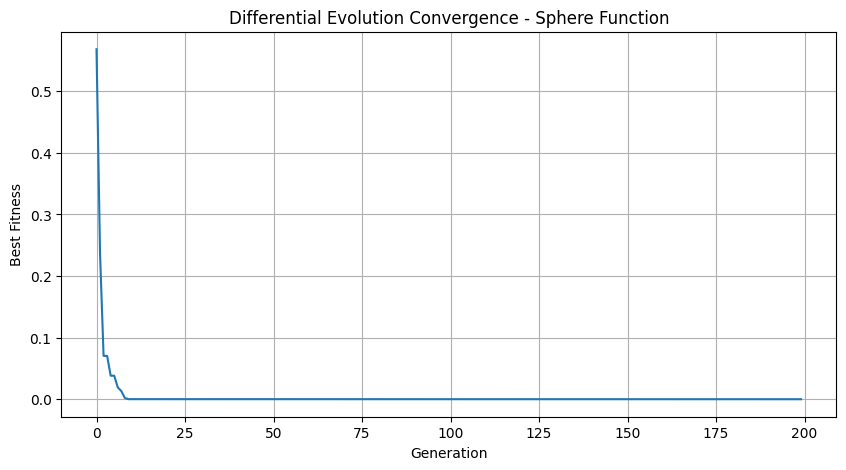

In [35]:
plt.figure(figsize=(10,5))

plt.plot(
    history
)
plt.xlabel(
    "Generation"
)
plt.ylabel(
    "Best Fitness"
)
plt.title(
    "Differential Evolution Convergence - Sphere Function"
)

plt.grid()
plt.show()

#### DE Convergence Analysis on Sphere Function

The convergence behavior of Differential Evolution was evaluated on the Sphere benchmark function.

##### Observation

The algorithm shows a rapid reduction in fitness during the early generations, indicating effective exploration of the search space.

After reaching a region close to the optimum, the improvement rate decreases and the algorithm performs fine-grained exploitation around the solution.

The fitness value approaches zero, which confirms that DE successfully converges toward the global optimum of the Sphere function:

$x^*=[0,0], \quad f(x^*)=0$

#### Conclusion

The results demonstrate the exploration-exploitation behavior of DE. Large vector differences in early generations allow broad search, while reduced differences between individuals near the optimum enable accurate convergence.

<h3> Step 8: Rosenbrock Function </h3>

The function:

$f(x_1,x_2) = (1-x_1)^2 + 100(x_2-x_1^2)^2$

Goal:
$$ minimize $$

Why is Rosenbrock harder?

Because it has a:

Narrow Valley.

Meaning:

The solution space resembles a narrow valley.

In [36]:
rosenbrock_function(
    np.array([1,1])
)

0

In [37]:
rosenbrock_function(
    np.array([0,0])
)

1

In [38]:
bounds_rosenbrock = [
    (-5,5),
    (-5,5)
]

result_rosenbrock = differential_evolution(
    rosenbrock_function,
    bounds_rosenbrock,
    population_size=50,
    generations=500,
    F=0.5,
    CR=0.7,
)

In [39]:
print(result_rosenbrock["solution"])
print(result_rosenbrock["fitness"])

[1. 1.]
0.0


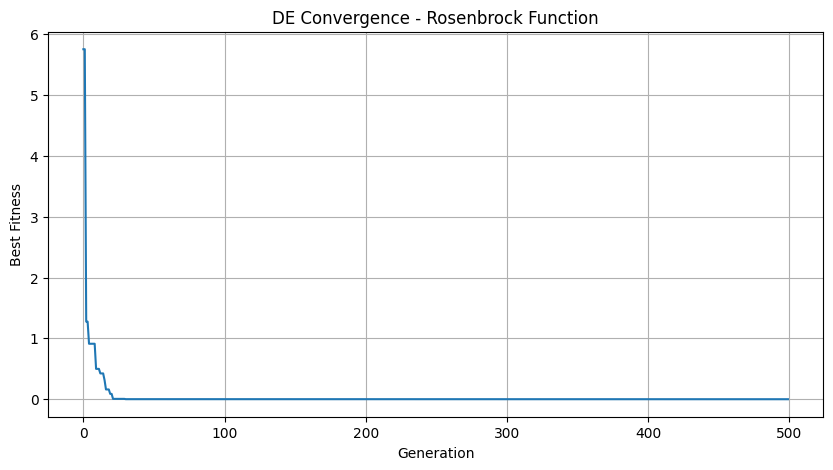

In [40]:
plt.figure(figsize=(10,5))

plt.plot(
    result_rosenbrock["history"]
)
plt.xlabel(
    "Generation"
)
plt.ylabel(
    "Best Fitness"
)
plt.title(
    "DE Convergence - Rosenbrock Function"
)

plt.grid()
plt.show()

#### DE Convergence Analysis on Rosenbrock Function

The performance of Differential Evolution was evaluated on the Rosenbrock benchmark function.

##### Observation

DE successfully converged to the global optimum:

$x^*=[1,1], \quad f(x^*)=0$

Compared with the Sphere function, the convergence is slower due to the narrow valley structure of the Rosenbrock landscape.

The algorithm initially performs a rapid exploration phase and then gradually refines the solution toward the optimum.

##### Conclusion

The results demonstrate that DE can effectively handle more complex continuous optimization problems by using population-based vector differences to guide the search process.

<h3> Step 9: Rastrigin Function </h3>

In [41]:
rastrigin_bounds = [
    (-5.12, 5.12),
    (-5.12, 5.12)
]

result_rastrigin = differential_evolution(
    rastrigin_function,
    rastrigin_bounds,
    population_size=50,
    generations=500,
    F=0.5,
    CR=0.7,
)

In [42]:
print(result_rastrigin["solution"])
print(result_rastrigin["fitness"])

[-1.20273268e-09  1.44595101e-09]
0.0


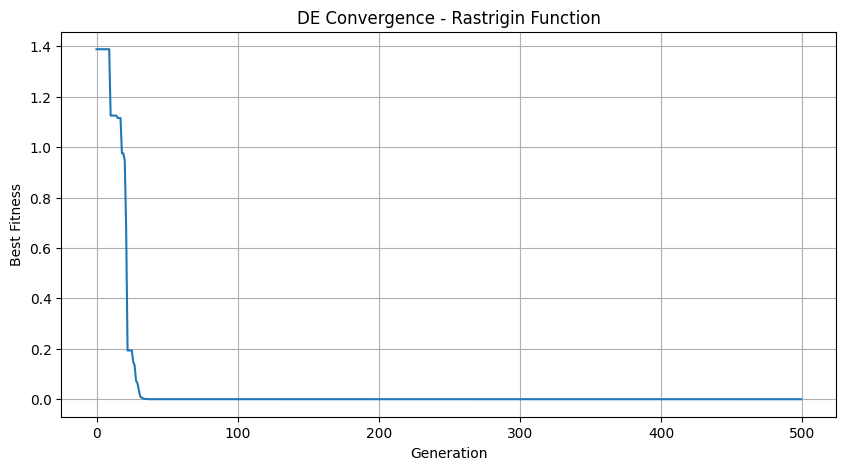

In [43]:
plt.figure(figsize=(10,5))

plt.plot(
    result_rastrigin["history"]
)
plt.xlabel(
    "Generation"
)
plt.ylabel(
    "Best Fitness"
)
plt.title(
    "DE Convergence - Rastrigin Function"
)

plt.grid()
plt.show()

#### DE Convergence Analysis on Rastrigin Function

The performance of Differential Evolution was evaluated on the Rastrigin benchmark function, which contains multiple local optima and a highly multimodal search landscape.

##### Observation

Despite the complex landscape, DE successfully escaped local optima and converged to the global optimum:

$x^* \approx [0,0]$

with:

$f(x^*)=0$

The convergence curve shows a rapid reduction in fitness during the early generations, followed by stabilization near the optimum.

##### Conclusion

The results demonstrate that DE has strong exploration capability due to its differential mutation mechanism. By using the differences between population vectors, DE can effectively search complex landscapes and avoid premature convergence on multimodal optimization problems.

<h3> Step 10: Plotting function graphs </h3>

In [44]:
def plot_function_surface(
    function,
    bounds,
    title,
    grid_size=200,
):
    x = np.linspace(
        bounds[0][0],
        bounds[0][1],
        grid_size,
    )

    y = np.linspace(
        bounds[1][0],
        bounds[1][1],
        grid_size,
    )

    X, Y = np.meshgrid(x, y)

    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            point = np.array(
                [X[i, j], Y[i, j]]
            )
            Z[i, j] = function(point)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        X,
        Y,
        Z,
    )

    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("f(x)")

    plt.show()

In [45]:
def plot_function_contour(
    function,
    bounds,
    title,
    grid_size=200,
):
    x = np.linspace(
        bounds[0][0],
        bounds[0][1],
        grid_size,
    )

    y = np.linspace(
        bounds[1][0],
        bounds[1][1],
        grid_size,
    )

    X, Y = np.meshgrid(x, y)

    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            point = np.array(
                [X[i, j], Y[i, j]]
            )
            Z[i, j] = function(point)

    plt.figure(figsize=(8, 6))

    plt.contour(
        X,
        Y,
        Z,
        levels=30,
    )

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid()
    plt.show()

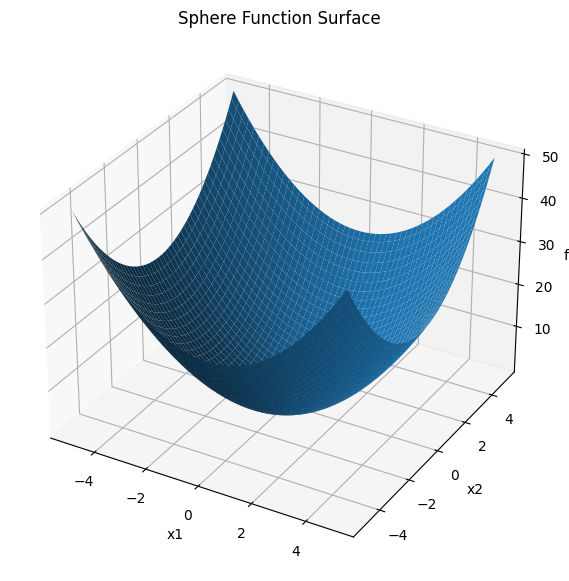

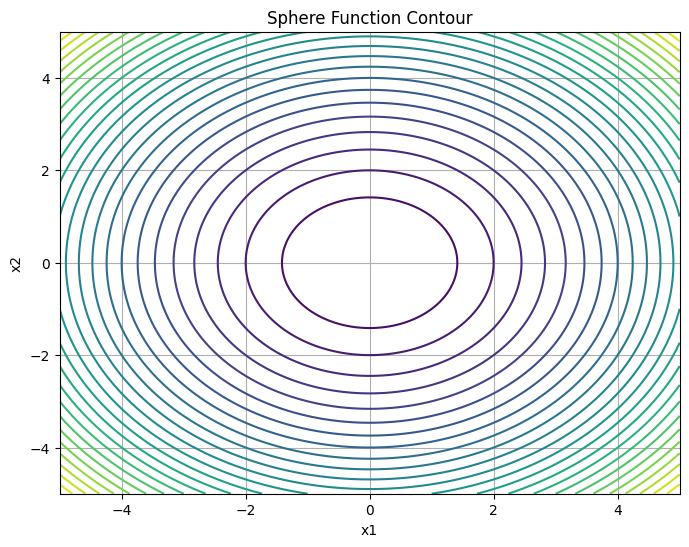

In [46]:
sphere_bounds = [
    (-5, 5),
    (-5, 5),
]

plot_function_surface(
    sphere_function,
    sphere_bounds,
    "Sphere Function Surface",
)

plot_function_contour(
    sphere_function,
    sphere_bounds,
    "Sphere Function Contour",
)

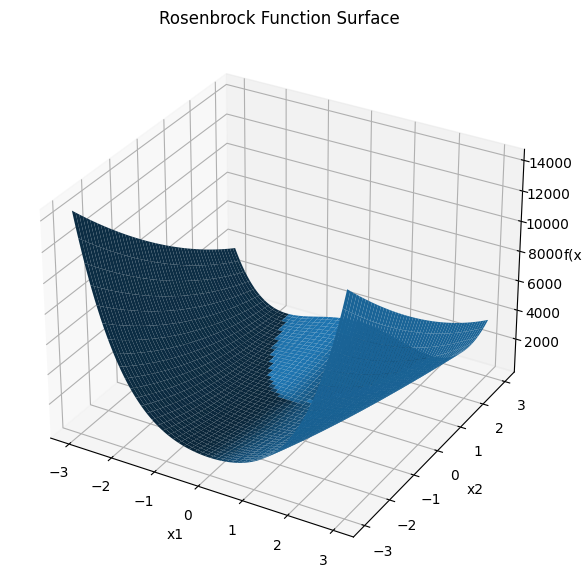

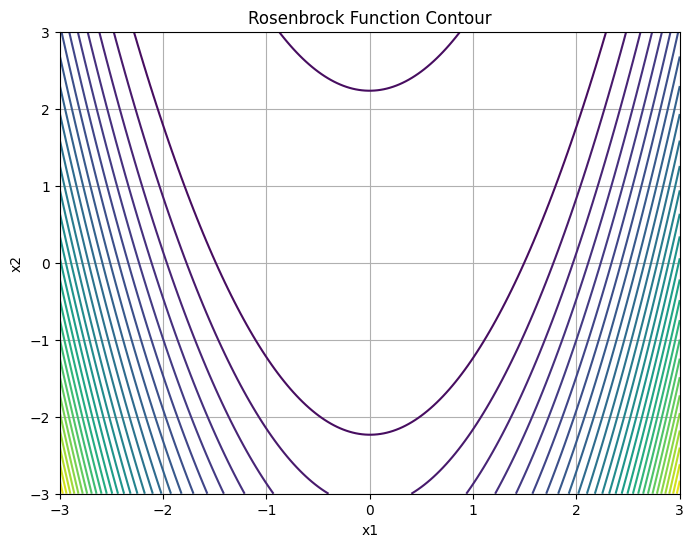

In [47]:
rosenbrock_bounds = [
    (-3, 3),
    (-3, 3),
]

plot_function_surface(
    rosenbrock_function,
    rosenbrock_bounds,
    "Rosenbrock Function Surface",
)

plot_function_contour(
    rosenbrock_function,
    rosenbrock_bounds,
    "Rosenbrock Function Contour",
)

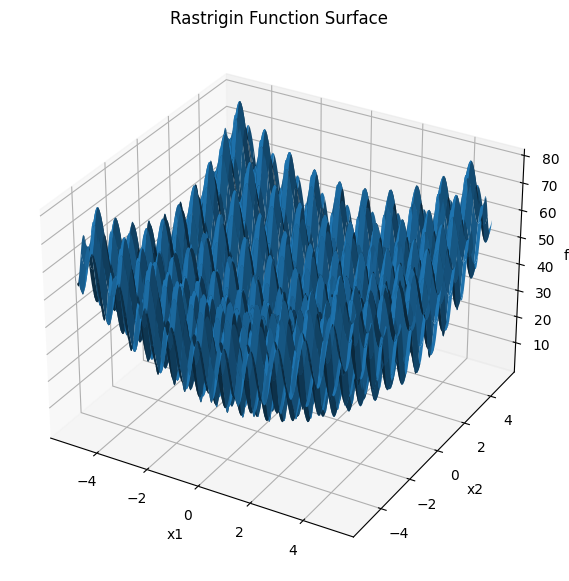

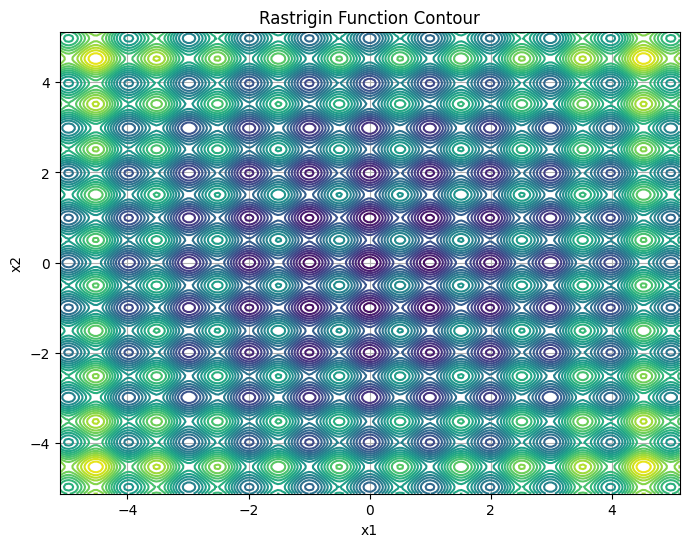

In [48]:
rastrigin_bounds = [
    (-5.12, 5.12),
    (-5.12, 5.12),
]

plot_function_surface(
    rastrigin_function,
    rastrigin_bounds,
    "Rastrigin Function Surface",
)

plot_function_contour(
    rastrigin_function,
    rastrigin_bounds,
    "Rastrigin Function Contour",
)

# Benchmark Function Visualization

Before evaluating Differential Evolution on different optimization problems, the landscape of benchmark functions was visualized to understand their difficulty and search characteristics.

These functions represent different optimization challenges, from simple convex landscapes to highly multimodal problems.

---

## 1. Sphere Function

The Sphere function is one of the simplest continuous optimization benchmarks:

$f(x)=\sum_{i=1}^{n}x_i^2$

The global optimum is:

$x^*=[0,0,...,0]$

with:

$f(x^*)=0$

### Characteristics:

- Convex and smooth landscape
- Only one global minimum
- No local optima
- Direct path toward the optimum

Because of its simple structure, most optimization algorithms can easily converge on this function.

---

## 2. Rosenbrock Function

The Rosenbrock function is a more challenging benchmark:

$f(x_1,x_2)=
(1-x_1)^2+
100(x_2-x_1^2)^2$

The global optimum is:

$x^*=[1,1]$

with:

$f(x^*)=0$

### Characteristics:

- Contains a narrow curved valley
- The global optimum is easy to define but difficult to reach
- Requires accurate search along the valley direction
- Tests the exploitation and convergence ability of optimization algorithms

Compared with Sphere, the algorithm must follow a more complex search trajectory.

---

## 3. Rastrigin Function

The Rastrigin function is a highly multimodal benchmark:

$f(x)=10n+\sum_{i=1}^{n}
(x_i^2-10\cos(2\pi x_i))$

The global optimum is:

$x^*=[0,0,...,0]$

with:

$f(x^*)=0$

### Characteristics:

- Contains many local optima
- Highly oscillatory landscape
- Requires strong exploration capability
- Suitable for evaluating the ability of algorithms to escape local minima

Unlike Sphere and Rosenbrock, the optimizer must balance exploration and exploitation carefully to avoid premature convergence.

---

## Comparison of Benchmark Landscapes

| Function | Difficulty | Main Challenge |
|---|---|---|
| Sphere | Easy | Basic convergence |
| Rosenbrock | Medium | Following a narrow optimum valley |
| Rastrigin | Hard | Escaping multiple local optima |

These benchmark functions provide a progressive evaluation framework for Differential Evolution, from simple optimization landscapes to complex multimodal search spaces.

## DE Parameter Effects

| Parameter | Increase Effect | Decrease Effect |
|---|---|---|
| F | Larger movements, more exploration, better escape from local optima | Smaller movements, stronger exploitation, faster refinement |
| CR | More mutant information, higher diversity | More conservative updates, stable convergence |
| Population Size | More diversity and better search coverage, higher computational cost | Faster execution but higher risk of premature convergence |

Proper parameter selection requires balancing exploration and exploitation according to the optimization problem.